# Show data preprocessing during data loading

## imports

In [96]:
import os
import yaml
import numpy as np
import pandas as pd
import pyBigWig

import seaborn as sns
import matplotlib.pyplot as plt

from figutils import (
    cm,
    set_figure_style, 
)

set_figure_style()

FIGS_DIR = os.path.join("pdfs","data_preprocessing")
os.makedirs(FIGS_DIR, exist_ok=True)

## data

In [122]:
# paths

ROOT = ".."
config = yaml.safe_load(open(os.path.join(ROOT,"config","config.yaml"),"r"))
SAMPLES = ["SRR17111301","SRR17111302","SRR17111303"] # WT technical replicates of biological replicate 1
SAMPLES = ["SRR17111301","SRR17111304","SRR17111307"] # WT biological replicates
SAMPLES = config["preprocessing"]["overfitting"]["samples"] # WT vs MUT
BIGWIG_STRANDS = ["forward","reverse"]
SINGLE_DIR = config["preprocessing"]["overfitting"]["single"]["output_dir"]

metadata_file = os.path.join(ROOT,"support","ENA_filereport-compendium-sf3b1mut.tsv")

interval_file = os.path.join(ROOT, SINGLE_DIR, "medium.bed")

bigwig_files = {
    sample: {
        strand: os.path.join(
            ROOT, config["rnaseq"]["sf3b1mut"]["path"], "STAR", sample, "paper_pass.Aligned.sortedByCoord.out.filtered." + strand + ".bw"
        )
        for strand in BIGWIG_STRANDS
    }
    for sample in SAMPLES
}

ssu_files = {
    sample: os.path.join(ROOT, config["rnaseq"]["sf3b1mut"]["path"], "STAR", sample, "paper_pass.ssu.parquet")
    for sample in SAMPLES
}

junction_files = {
    sample: os.path.join(ROOT, config["rnaseq"]["sf3b1mut"]["path"], "STAR", sample, "paper_pass.SJ.out.tab")
    for sample in SAMPLES
}

In [123]:
# loads

metadata = pd.read_table(metadata_file)

interval = pd.read_table(interval_file, header=None, names=["chrom", "start", "end"])

chrom_oi = interval["chrom"].iloc[0]
start_oi = interval["start"].iloc[0]
end_oi = interval["end"].iloc[0]
seq_len = end_oi - start_oi

bigwigs = {
    sample: {strand: pyBigWig.open(f).values(chrom_oi, start_oi, end_oi, numpy=True) for strand, f in strands.items()}
    for sample, strands in bigwig_files.items()
}

filters = [
    ("chrom", "==", chrom_oi),
    ("exon_pos", ">=", start_oi),
    ("exon_pos", "<=", end_oi),
]

ssus = pd.concat(
    [
        pd.read_parquet(f, filters=filters).assign(sample=s)
        for s, f in ssu_files.items()
    ],
    ignore_index=True
)

junctions = pd.concat(
    [
        pd.read_table(
            f,
            header=None,
            names=[
                "chrom",
                "intron_start",
                "intron_end",
                "strand_code",
                "intron_motif",
                "annotated",
                "n_uniquely_mapped_reads",
                "n_multi_mapped_reads",
                "max_overhang",
            ],
        )
        .assign(
            sample=s,
            exon_start=lambda d: d["intron_start"] - 1,
            exon_end=lambda d: d["intron_end"] + 1,
            strand=lambda d: d["strand_code"].astype(str).map(
                {"0": ".", "1": "+", "2": "-"}
            ).fillna("."),
            count=lambda d: pd.to_numeric(
                d["n_uniquely_mapped_reads"], errors="coerce"
            )
        )
        .query(
            "chrom.str.contains('chr') & strand.isin(['+','-']) & count > 1"
        )
        for s, f in junction_files.items()
    ],
    ignore_index=True
)

## preprocessing RNA-seq coverage

Scale by mean non-zero coverage across all intervals (here only one)

In [99]:
bigwigs

{'SRR17111303': {'forward': array([0., 0., 0., ..., 0., 0., 0.], shape=(1048576,), dtype=float32),
  'reverse': array([0., 0., 0., ..., 0., 0., 0.], shape=(1048576,), dtype=float32)},
 'SRR17111311': {'forward': array([0., 0., 0., ..., 0., 0., 0.], shape=(1048576,), dtype=float32),
  'reverse': array([0., 0., 0., ..., 0., 0., 0.], shape=(1048576,), dtype=float32)}}

In [100]:
coverage = np.stack([
    vec
    for sample in bigwigs.values()
    for vec in sample.values()
])
coverage

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(4, 1048576), dtype=float32)

In [101]:
track_nonzero_sums = np.zeros(coverage.shape[0], dtype=np.float64)
track_nonzero_counts = np.zeros(coverage.shape[0], dtype=np.int64)

i=0
for sample in bigwigs.values():
    for values in sample.values():
        values = np.asarray(values, dtype=np.float32)
        values = np.nan_to_num(values, nan=0.0)

        # Only count non-zero values for nonzero_mean
        nonzero_vals = values[values != 0]
        track_nonzero_sums[i] += nonzero_vals.sum()
        track_nonzero_counts[i] += len(nonzero_vals)
        
        i += 1
        
track_means = np.where(
    track_nonzero_counts > 0,
    track_nonzero_sums / track_nonzero_counts,
    1.0,
)

track_means

array([18.18268174, 47.26276331, 18.5533517 , 38.15060928])

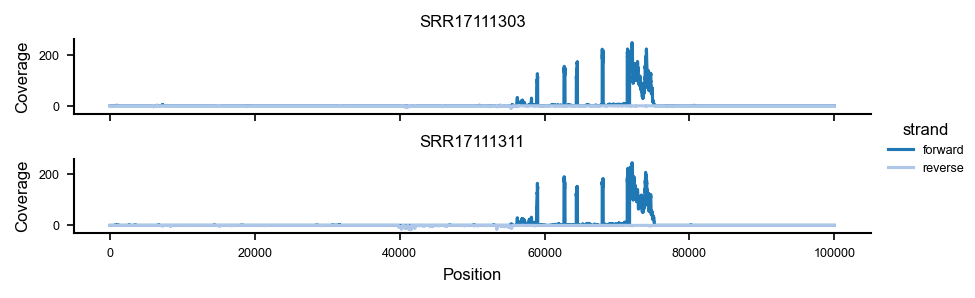

In [102]:
strand_order = ["forward", "reverse"]

track_info = [
    {"sample": sample, "strand": strand, "track": f"{sample} ({strand})"}
    for sample in sorted(bigwigs)
    for strand in strand_order
]

X = (
    pd.DataFrame(coverage[:,:100_000])
    .assign(
        sample = [x["sample"] for x in track_info],
        strand = [x["strand"] for x in track_info],
        track = [x["track"] for x in track_info],
    )
    .melt(
        id_vars=["sample", "strand", "track"],
        var_name="position",
        value_name="coverage"
    )
)
X.loc[X["strand"]=="reverse","coverage"] = -X.loc[X["strand"]=="reverse","coverage"]

g = sns.relplot(
    data=X,
    kind="line",
    x="position",
    y="coverage",
    hue="strand", palette="tab20",
    row="sample",
    height=2.5*cm,
    aspect=6,
    facet_kws={"sharey": True, "sharex": True},
)

g.set_axis_labels("Position", "Coverage")
g.set_titles("{row_name}")

g.fig.savefig(os.path.join(FIGS_DIR,"positions_vs_coverage_raw-line.pdf"), bbox_inches="tight", dpi=200)

plt.show()

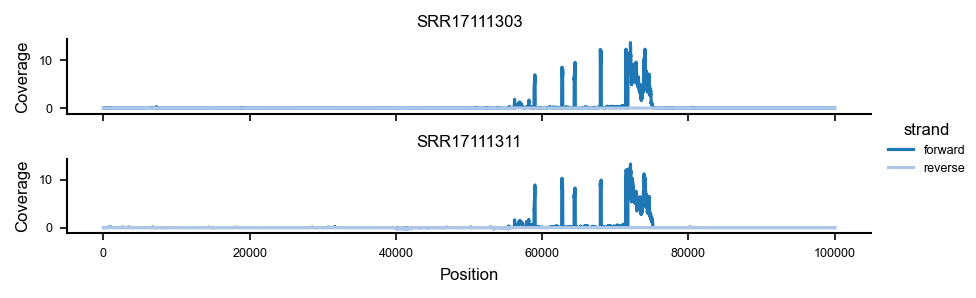

In [103]:
strand_order = ["forward", "reverse"]

track_info = [
    {"sample": sample, "strand": strand, "track": f"{sample} ({strand})"}
    for sample in sorted(bigwigs)
    for strand in strand_order
]

X = (
    pd.DataFrame(coverage[:,:100_000] / track_means.reshape(-1,1))
    .assign(
        sample = [x["sample"] for x in track_info],
        strand = [x["strand"] for x in track_info],
        track = [x["track"] for x in track_info],
    )
    .melt(
        id_vars=["sample", "strand", "track"],
        var_name="position",
        value_name="coverage"
    )
)
X.loc[X["strand"]=="reverse","coverage"] = -X.loc[X["strand"]=="reverse","coverage"]

g = sns.relplot(
    data=X,
    kind="line",
    x="position",
    y="coverage",
    hue="strand", palette="tab20",
    row="sample",
    height=2.5*cm,
    aspect=6,
    facet_kws={"sharey": True, "sharex": True},
)

g.set_axis_labels("Position", "Coverage")
g.set_titles("{row_name}")

g.fig.savefig(os.path.join(FIGS_DIR,"positions_vs_coverage_scaled-line.pdf"), bbox_inches="tight", dpi=200)

plt.show()

## splice site classifications extracted from SSU table

One-hot encode donors and acceptors in each strand:
- 0: Donor on + strand
- 1: Acceptor on + strand
- 2: Donor on - strand
- 3: Acceptor on - strand
- 4: None (background)

One track across all samples.

In [104]:
splice_sites = np.zeros((seq_len, 5), dtype=np.float32)
splice_sites[:, 4] = 1.0

site_types = {
    0: {"strand":"+", "role":"donor"},
    1: {"strand":"+", "role":"acceptor"},
    2: {"strand":"-", "role":"donor"},
    3: {"strand":"-", "role":"acceptor"},
}
for site_idx, site_type in site_types.items():
    idxs = ssus.query("strand==@site_type['strand'] & role==@site_type['role']")["exon_pos"].astype("int").unique() - 1 - start_oi
    splice_sites[idxs, 4] = 0.0
    splice_sites[idxs, site_idx] = 1.0
    
splice_sites.sum(axis=0).astype(int)

array([     63,      64,     181,     177, 1048091])

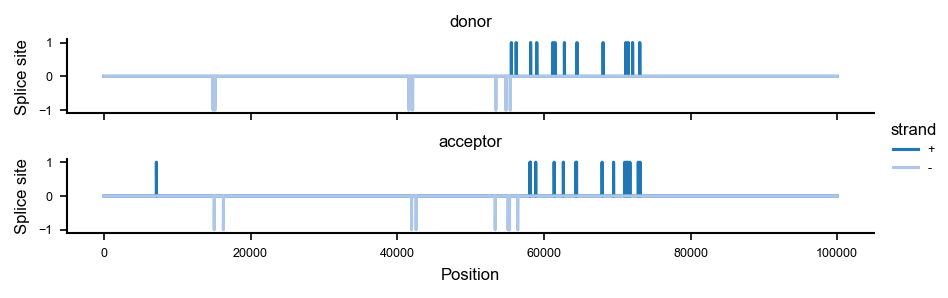

In [105]:
site_info = {
    0: {"strand": "+", "role": "donor", "track": "+ donor"},
    1: {"strand": "+", "role": "acceptor", "track": "+ acceptor"},
    2: {"strand": "-", "role": "donor", "track": "- donor"},
    3: {"strand": "-", "role": "acceptor", "track": "- acceptor"},
    4: {"strand": ".", "role": "none", "track": "none"},
}

X = (
    pd.DataFrame(splice_sites[:100_000, :4].T)   # shape: 4 x seq_len
    .assign(
        strand=[site_info[i]["strand"] for i in range(4)],
        role=[site_info[i]["role"] for i in range(4)],
        track=[site_info[i]["track"] for i in range(4)],
    )
    .melt(
        id_vars=["strand", "role", "track"],
        var_name="position",
        value_name="is_site"
    )
)

X.loc[X["strand"] == "-", "is_site"] *= -1

g = sns.relplot(
    data=X,
    kind="line",
    x="position",
    y="is_site",
    hue="strand", palette="tab20",
    row="role",
    height=2.5*cm,
    aspect=6,
    facet_kws={"sharey": True, "sharex": True},
)

g.set_axis_labels("Position", "Splice site")
g.set_titles("{row_name}")

g.fig.savefig(os.path.join(FIGS_DIR,"positions_vs_splise_site_types-line.pdf"), bbox_inches="tight", dpi=200)

plt.show()

## SSU is ready to use

In [106]:
ssu_arrs = {}

for sample in ssus["sample"].unique():

    pos_arr = np.zeros(seq_len, dtype=np.float32)
    neg_arr = np.zeros(seq_len, dtype=np.float32)
    
    idxs = ssus.query("strand=='+' & sample==@sample")["exon_pos"].astype("int") - 1 - start_oi
    vals = ssus.query("strand=='+' & sample==@sample")["ssu_spliser"]
    pos_arr[idxs] = vals
    
    idxs = ssus.query("strand=='-' & sample==@sample")["exon_pos"].astype("int") - 1 - start_oi
    vals = ssus.query("strand=='-' & sample==@sample")["ssu_spliser"]
    neg_arr[idxs] = vals

    ssu_arrs[sample] = {"forward": pos_arr, "reverse": neg_arr}
    
ssu_arrs

{'SRR17111303': {'forward': array([0., 0., 0., ..., 0., 0., 0.], shape=(1048576,), dtype=float32),
  'reverse': array([0., 0., 0., ..., 0., 0., 0.], shape=(1048576,), dtype=float32)},
 'SRR17111311': {'forward': array([0., 0., 0., ..., 0., 0., 0.], shape=(1048576,), dtype=float32),
  'reverse': array([0., 0., 0., ..., 0., 0., 0.], shape=(1048576,), dtype=float32)}}

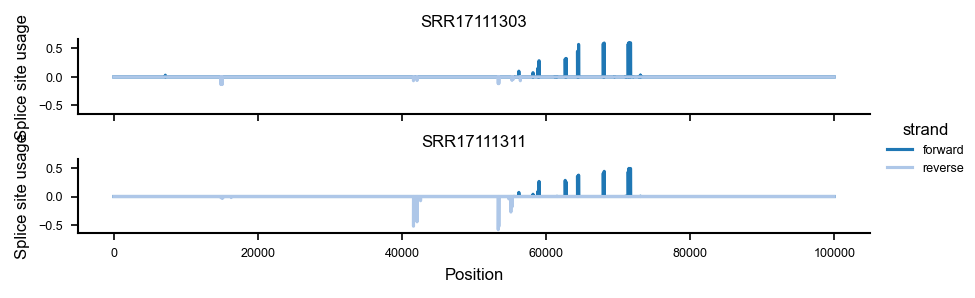

In [107]:
n = 100_000

X = pd.concat(
    [
        pd.DataFrame({
            "position": np.arange(n),
            "ssu": ssu[:n],
        }).assign(sample=sample, strand=strand)
        for sample, strands in ssu_arrs.items()
        for strand, ssu in strands.items()
    ],
    ignore_index=True
)

X.loc[X["strand"] == "reverse", "ssu"] *= -1

g = sns.relplot(
    data=X,
    kind="line",
    x="position",
    y="ssu",
    hue="strand", palette="tab20",
    row="sample",
    height=2.5*cm,
    aspect=6,
    facet_kws={"sharey": True, "sharex": True},
)

g.set_axis_labels("Position", "Splice site usage")
g.set_titles("{row_name}")

g.fig.savefig(os.path.join(FIGS_DIR,"positions_vs_splise_site_usage-line.pdf"), bbox_inches="tight", dpi=200)

plt.show()

## splice junctions

CPM normalized, 99th percentile clipping, scaled by non-zero mean.

In [108]:
def normalize_junctions(junc_df: pd.DataFrame) -> pd.DataFrame:
    df = junc_df.copy()

    # Step 1: CPM normalize
    total_reads = df["count"].sum()
    if total_reads > 0:
        df["cpm"] = (df["count"] / total_reads) * 1e6
    else:
        return df  # All zeros, return as-is

    # Step 2: Clip at 99.99th percentile
    threshold = float(np.percentile(df["cpm"], 99.99))
    df["clipped"] = np.minimum(df["cpm"], threshold)

    # Step 3: Scale by mean of nonzero values
    nonzero = df.loc[df["clipped"] > 0, "clipped"]
    if len(nonzero) > 0:
        mean_val = float(nonzero.mean())
        if mean_val > 0:
            df["scaled"] = df["clipped"] / mean_val

    return df

junctions = junctions.groupby("sample").apply(normalize_junctions).reset_index()

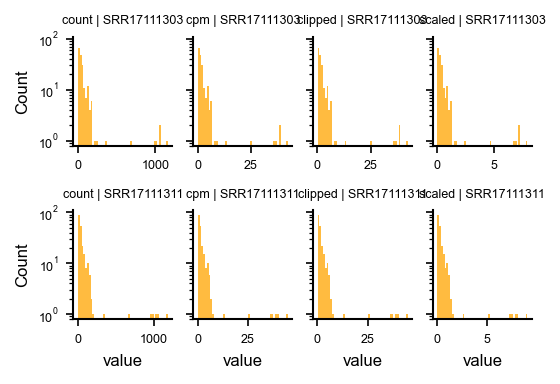

In [115]:
X = (
    junctions
    .query(
        "chrom == @chrom_oi & "
        "exon_start > @start_oi & exon_start <= @end_oi & "
        "exon_end > @start_oi & exon_end <= @end_oi"
    )
    .melt(id_vars=["sample","chrom","exon_start","exon_end","strand"], value_vars=["count","cpm","clipped","scaled"])
)

g = sns.displot(
    kind="hist",
    data=X,
    x="value",
    color="orange",
    col="variable",
    row="sample",
    bins=50,
    common_bins=False,
    facet_kws=dict(sharex=False),
    height=3.25*cm, aspect=0.7
)

g.set(yscale="log")
g.set_titles("{col_name} | {row_name}")
for ax in g.axes.flat:
    ax.title.set_size(6)
    
g.fig.savefig(os.path.join(FIGS_DIR,"splice_junctions_prep-hist.pdf"), bbox_inches="tight", dpi=200)

plt.show()

In [116]:
# number of junctions in interval

X[["sample","chrom","exon_start","exon_end","strand"]].drop_duplicates().value_counts("sample")

sample
SRR17111311    213
SRR17111303    195
Name: count, dtype: int64